# SQLite and Visuals

Import libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np


Import HPI and Median Income csv files

In [2]:
hpi_df = pd.read_csv('data/hpi_clean.csv')
med_inc_df = pd.read_csv('data/median_income_clean_w_change.csv')

Create/open SQLite 3 database hpi_v_medic.db and create cursor object to execute commands

In [3]:
conn = sqlite3.connect("hpi_v_medinc.db")
cursor = conn.cursor()

Creation of hpi and medic tables for hpi_v_medinc.db/writing Pandas dataframes to the database. Then verify

In [4]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS hpi (
    hpi_type TEXT NOT NULL,
    hpi_flavor TEXT NOT NULL,
    frequency TEXT PRIMARY KEY,
    level TEXT NOT NULL,
    place_name REAL NOT NULL,
    yr TEXT NOT NULL,
    index_nsa TEST NOT NULL          
);        
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS medinc (
    place_name TEXT NOT NULL,
    yr TEXT NOT NULL,
    median_income TEXT NOT NULL,
    change TEXT NOT NULL
);
""")

hpi_df.to_sql('hpi', conn, if_exists='replace', index=False)
med_inc_df.to_sql('medinc', conn, if_exists='replace', index=False)

print(pd.read_sql_query("SELECT * FROM hpi LIMIT 5", conn))
print(pd.read_sql_query("SELECT * FROM medinc LIMIT 5", conn))

      hpi_type     hpi_flavor  frequency  level place_name place_id    yr  \
0  traditional  purchase-only  quarterly  State     Alaska       AK  1991   
1  traditional  purchase-only  quarterly  State     Alaska       AK  1992   
2  traditional  purchase-only  quarterly  State     Alaska       AK  1993   
3  traditional  purchase-only  quarterly  State     Alaska       AK  1994   
4  traditional  purchase-only  quarterly  State     Alaska       AK  1995   

   period  index_nsa  index_sa  
0       1       0.00    100.00  
1       1       3.06    103.01  
2       1       5.16    105.02  
3       1      11.51    111.26  
4       1      14.80    114.52  
  place_name    yr median_income  change standard_error
0    Alabama  1991        24,350    0.00          1,068
1    Alabama  1992        25,810    6.00          1,058
2    Alabama  1993        25,080    3.00          1,088
3    Alabama  1994        27,200   11.70          1,559
4    Alabama  1995        25,990    6.74          1,266


Function to run queries

In [5]:
def query(query: str):
    return pd.read_sql(query, conn)

## Begin Analysis of Data

### In this analysis I will be comparing the growth the Housing Price Index (HPI) to the growth in Median Income across the 50 states from 1991 to 2024. Both HPI and Median Income are indexed to a common year (1991) and values are a percent change relative to that year. 1991 has a value of 0 which represents the baseline for this analysis. 

Initial INNER JOIN that will be used in a choropleth map visualization. This query returns the gap between HPI and Median Income for the year 2024 returning all states. 

In [6]:
main_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
""")




Function containing a query to determine the eight states with the lowest gap between HPI and Median Income and code for grouped bar chart visualization


In [7]:
def lowest_gap_bar(year):

    df = query(f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.yr = {year}
    ORDER BY gap ASC
    LIMIT 8
    """)

    x = np.arange(len(df))
    width = 0.35

    plt.figure(figsize=(15, 7))

    plt.bar(x - width/2, df['hpi'], width, color="#4f4da7", label='HPI')
    plt.bar(x + width/2, df['income_index'], width, color="#A5A74D", label='Income')

    plt.xticks(x, df['place_name'], rotation=45, ha='right')
    plt.title(f'States with the Lowest HPI to Income Gap {year}', fontsize=16)
    plt.ylabel('% Change')

    plt.legend(loc='upper left', fontsize=13)
    plt.grid(axis='y', alpha=0.3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()





Call the function by choosing a year between 1991 and 2024 as the argument

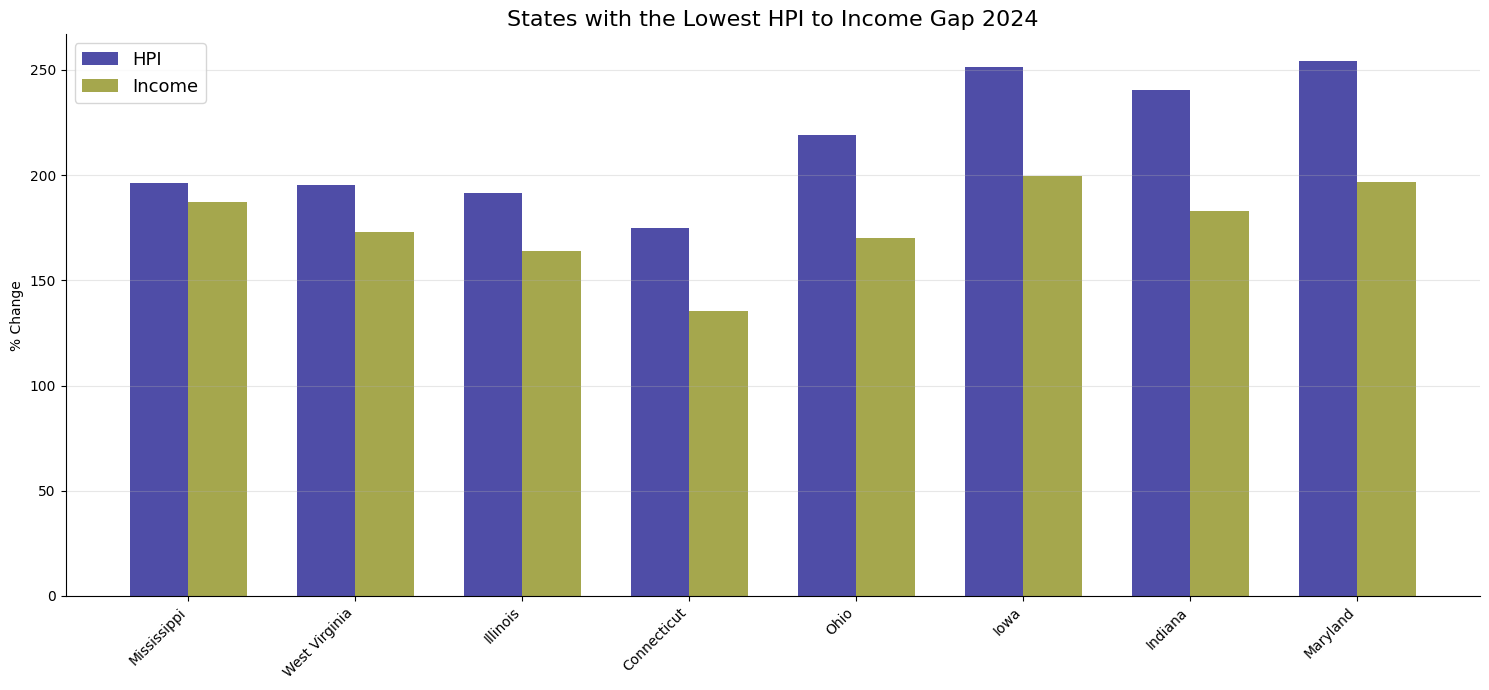

In [8]:
lowest_gap_bar(2024)

Function containing a query to determine the eight states with the largest gap between HPI and Median Income and code for grouped bar chart visualization

In [9]:
def largest_gap_bar(year):

    df = query("""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.yr = 2024
    ORDER BY gap DESC
    Limit 8
    """)

    df = df.sort_values('hpi', ascending=False)

    x = np.arange(len(df))
    width = 0.35

    plt.figure(figsize=(15, 7))

    plt.bar(x - width/2, df['hpi'], width, color="#4f4da7", label='HPI')
    plt.bar(x + width/2, df['income_index'], width, color="#A5A74D", label='Income')

    plt.xticks(x, df['place_name'], rotation=45, ha='right')
    plt.title(f'States with the Highest HPI to Income Gap {year}', fontsize=16,)
    plt.ylabel('% Change')
    
    plt.legend(loc='upper right', fontsize=13)
    plt.grid(axis='y', alpha=0.3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()



Call the function by choosing a year between 1991 and 2024 as the argument

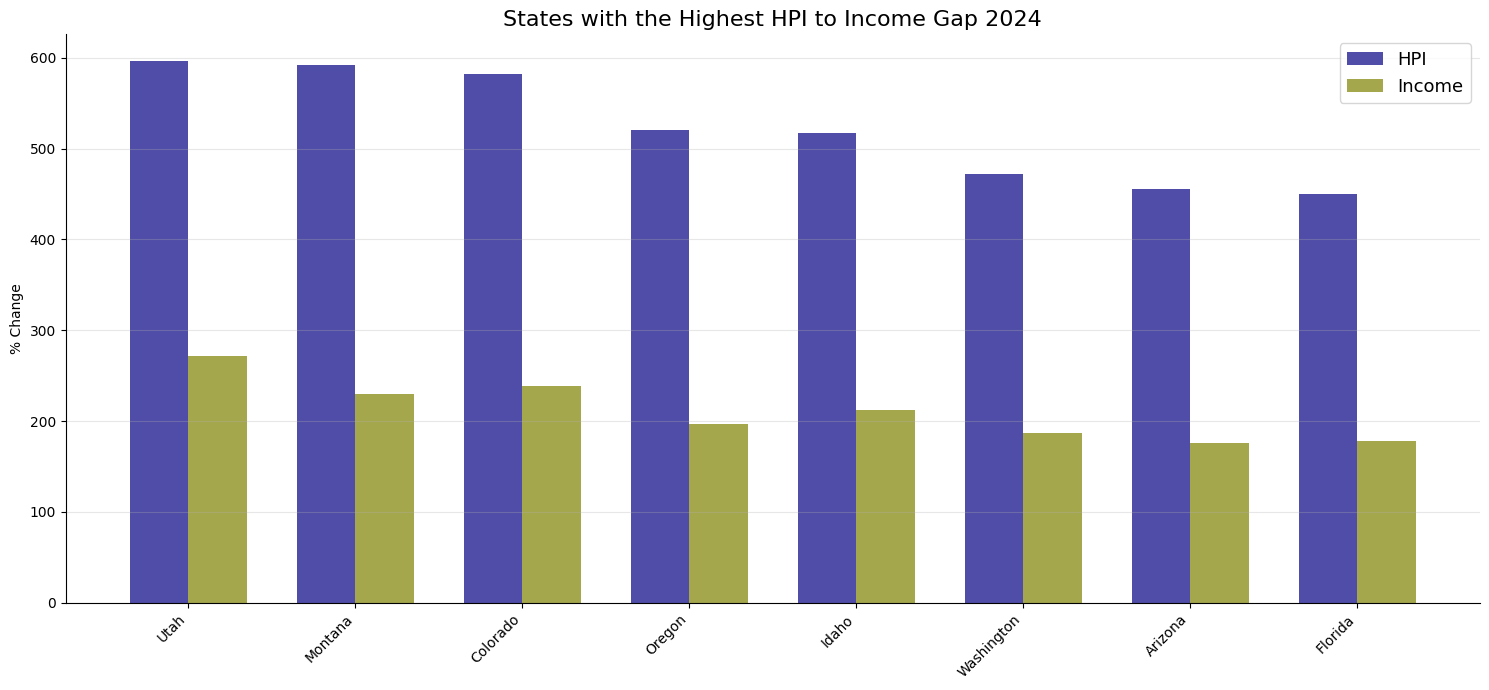

In [10]:
largest_gap_bar(2024)

Function which includes a query to show long term affordability by state in the years 1991 - 2024 and code for line graph 

In [11]:
def affordability_over_time(state):
    
    df = query(f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name = '{state}'
    ORDER BY h.yr
    """)

    
    plt.figure(figsize=(12, 6))

    plt.plot(df['yr'], df['gap'], linewidth=2.5, color="#4f4da7")
    
    plt.axhline(0, linestyle='--', linewidth=1)
    
    x = df['yr'].iloc[-1]
    y = df['gap'].iloc[-1]
    plt.text(x + 0.2, y, f"{y:.1f}", fontsize=10,)
    
    plt.title(f'{state}\nHousing Affordability 1991 - 2024', fontsize=16,)
    plt.xlabel('Year')
    plt.ylabel('Gap (HPI - Income Index)')

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Call the function using any state as the arguement

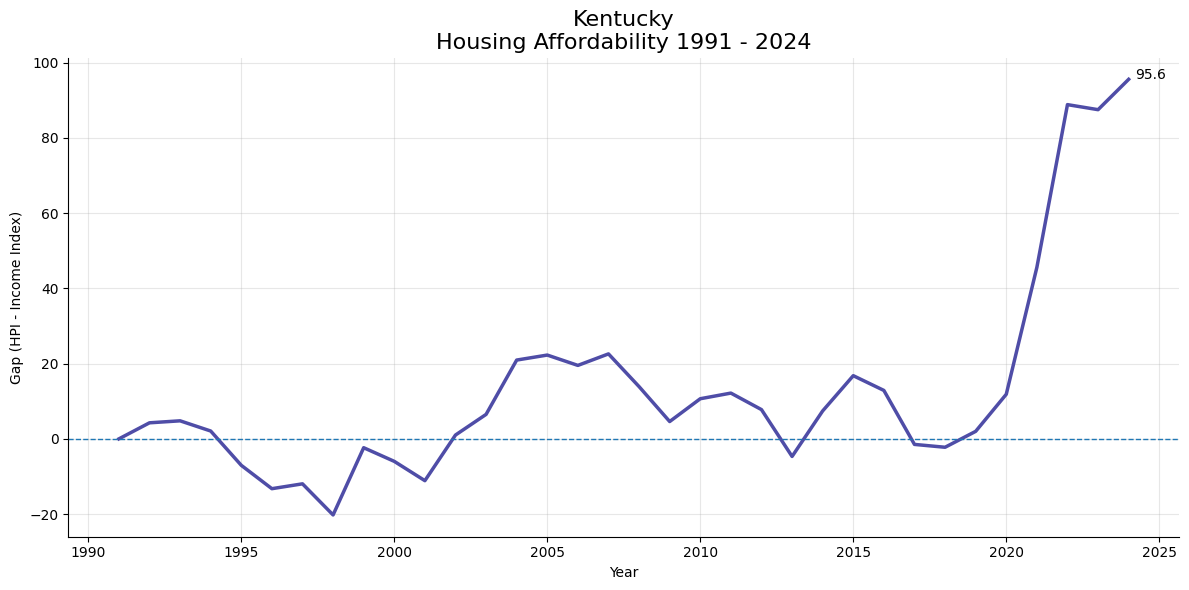

In [12]:
affordability_over_time('Kentucky')

Function which includes a query to compare the HPI v Median Income gap for any two states 1991 to 2024 and code for the line graph visual. Loop: determine states for df, loop through both and create df with requested data for each state, code to plot line where x-axis = year and y-axis = gap, code to add last gap value at end of line

In [30]:
def compare_states_with_gap(state1, state2):
    df = query(f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name IN ('{state1}', '{state2}')
    ORDER BY h.place_name, h.yr
    """)

    plt.figure(figsize=(12, 6))

    color_map = {
        state1: '#4f4da7',
        state2: '#A5A74D'
    }

    for state in df['place_name'].unique():
        subset = df[df['place_name'] == state]

        plt.plot(subset['yr'], subset['gap'], linewidth=2.5, markersize=5, label=state, color=color_map[state])
        
        x = subset['yr'].iloc[-1]
        y = subset['gap'].iloc[-1]

        plt.text(x + 0.2, y, f"{y:.1f}", fontsize=10)     
        
   
    plt.axhline(0, linestyle='--', linewidth=1)
    
    plt.title(f'HPI vs Median Income Gap Over Time:\n{state1} - {state2}', fontsize=16,)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Gap (HPI - Income Index)', fontsize=12)
    
    plt.grid(alpha=0.3)
    plt.legend(title='State', fontsize=10)
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Call the function by using two states as the arguements

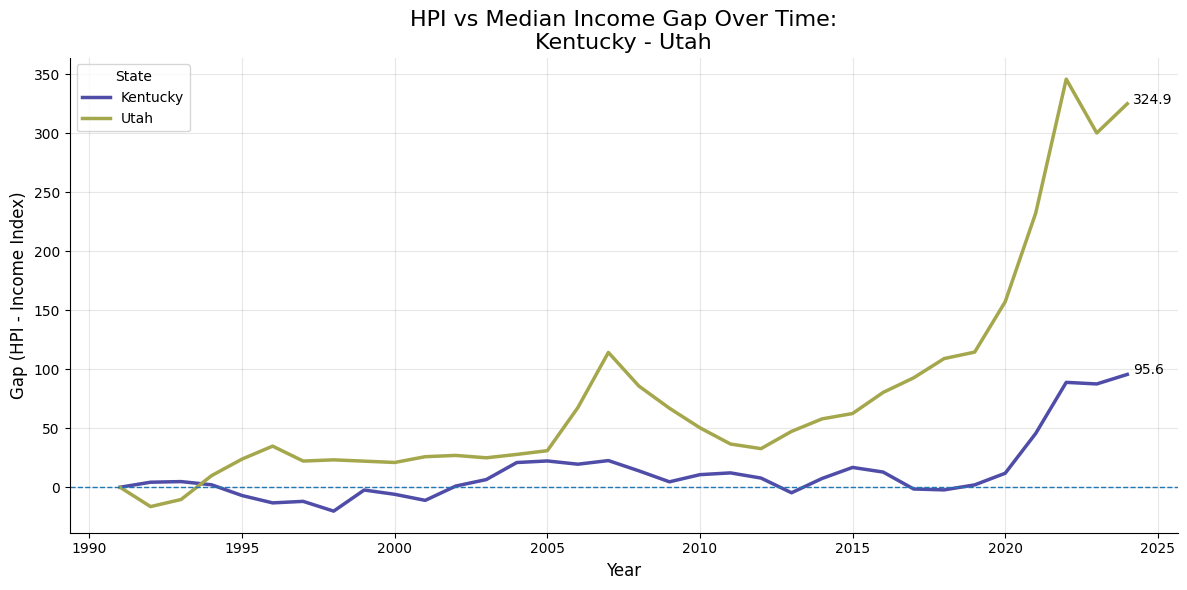

In [31]:
compare_states_with_gap('Kentucky', 'Utah')

Function which includes a query that returns both HPI increase and Median Income increase from 1991 - 2024 for any state and code for the line graph visualization

In [15]:
def plot_state_hpi_vs_income(state):

    df = query(f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name = '{state}'
    ORDER BY h.yr
    """)

    subset = df[df['place_name'] == state]

    plt.figure(figsize=(12, 6))

    plt.plot(subset['yr'], subset['hpi'], linewidth=2.5, linestyle='-', color="#4f4da7", label='HPI')

    plt.plot(subset['yr'], subset['income_index'], linewidth=2.5, linestyle='-', color="#A5A74D", label='Median Income')

    x_last = subset['yr'].iloc[-1]

    hpi_last = subset['hpi'].iloc[-1]
    income_last = subset['income_index'].iloc[-1]

    plt.text(x_last + 0.2, hpi_last, f"{hpi_last:.1f}", fontsize=10)
    plt.text(x_last + 0.2, income_last, f"{income_last:.1f}", fontsize=10)

    plt.title(f'{state}: HPI Increase vs Income Growth', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('% Change')

    plt.grid(alpha=0.3)
    plt.legend()

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Call the function by choosing any state

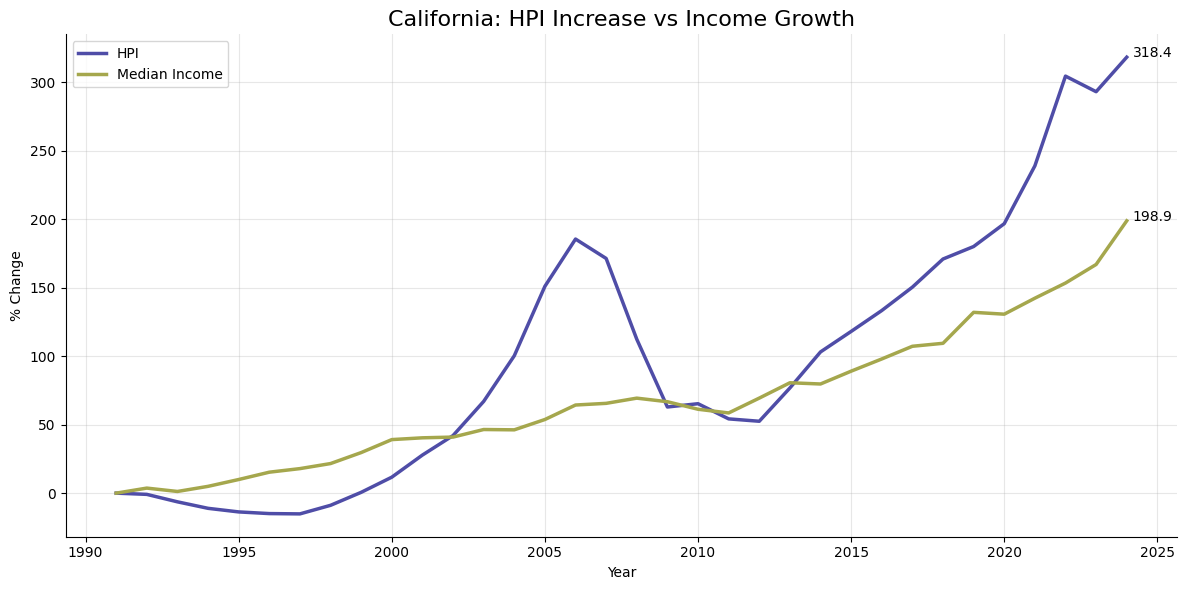

In [16]:
plot_state_hpi_vs_income('California')

Beginning of choropleth map visualization. Created dictionary of states and specific two letter abbreviations for the Plotly choropleth map as the actual state names cannot be used. 

In [17]:
state_map = {
    'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR',
    'California': 'CA','Colorado': 'CO','Connecticut': 'CT','Delaware': 'DE',
    'Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID',
    'Illinois': 'IL','Indiana': 'IN','Iowa': 'IA','Kansas': 'KS',
    'Kentucky': 'KY','Louisiana': 'LA','Maine': 'ME','Maryland': 'MD',
    'Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN','Mississippi': 'MS',
    'Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV',
    'New Hampshire': 'NH','New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY',
    'North Carolina': 'NC','North Dakota': 'ND','Ohio': 'OH','Oklahoma': 'OK',
    'Oregon': 'OR','Pennsylvania': 'PA','Rhode Island': 'RI','South Carolina': 'SC',
    'South Dakota': 'SD','Tennessee': 'TN','Texas': 'TX','Utah': 'UT',
    'Vermont': 'VT','Virginia': 'VA','Washington': 'WA','West Virginia': 'WV',
    'Wisconsin': 'WI','Wyoming': 'WY'
}

Create a new column in the dataframe created earlier (main_gap_df) called 'place_id' and use the dictionary to assign the corresponding two letter abbreviation

In [18]:
main_gap_df['place_id'] = main_gap_df['place_name'].map(state_map)

Verify column and abbreviations

In [19]:
main_gap_df[['place_name','place_id']].head()

,place_name,place_id
0,Montana,MT
1,Colorado,CO
2,Utah,UT
3,Oregon,OR
4,Idaho,ID


Code for choropleth map of the percentage point gap between HPI and Median Income for all states using a color scale where dark blue is the lowest and deep red is the highest. Hovering over state will display the state's gap between HPI and Median Income

In [20]:
fig = px.choropleth(
    main_gap_df,
    locations='place_id',
    locationmode='USA-states',
    scope='usa',
    color='gap',
    color_continuous_scale='Jet',   
    range_color=[0, 400],
    hover_name='place_name',              
    hover_data={
        'place_id': False,
        'gap': ':.2f'
    },
    title='Housing vs Income Gap by State (2024)'

)
fig.update_layout(height=500, width=800)
fig.update_layout(title_text='Housing vs Income Gap Percentage Point Difference by State (2024)', title_x=0.5)
fig.show()

Function which includes a query to compare HPI to Median Income and display the results in a scatterplot to clearly see which states are more affordable to live in and which are the most expensive. Loop through each state to obtain x-coordinate (income) and y-coordinate (hpi). TO DO - Maybe work in dictionary similar to choropleth for easier readability

In [21]:
def hpi_vs_income_scatter(year):

    df = query(f"""
    SELECT
        h.place_name,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.yr = {year}
    """)

    plt.figure(figsize=(20, 11))

    plt.scatter(df['income_index'], df['hpi'], alpha=0.7, color="#4f4da7")

    for l, row in df.iterrows():
        plt.text(row['income_index'] + 1, row['hpi'], row['place_name'], fontsize=9)
  
  

    max_val = max(df['hpi'].max(), df['income_index'].max())
    plt.plot([0, max_val], [0, max_val], linestyle='--', color="#4f4da7")
    
    plt.title(f'HPI vs Income {year}', fontsize=16)
    plt.xlabel('Income Growth (%)')
    plt.ylabel('HPI Growth (%)')

    plt.grid(alpha=0.3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Call the function by using a year as the arguement

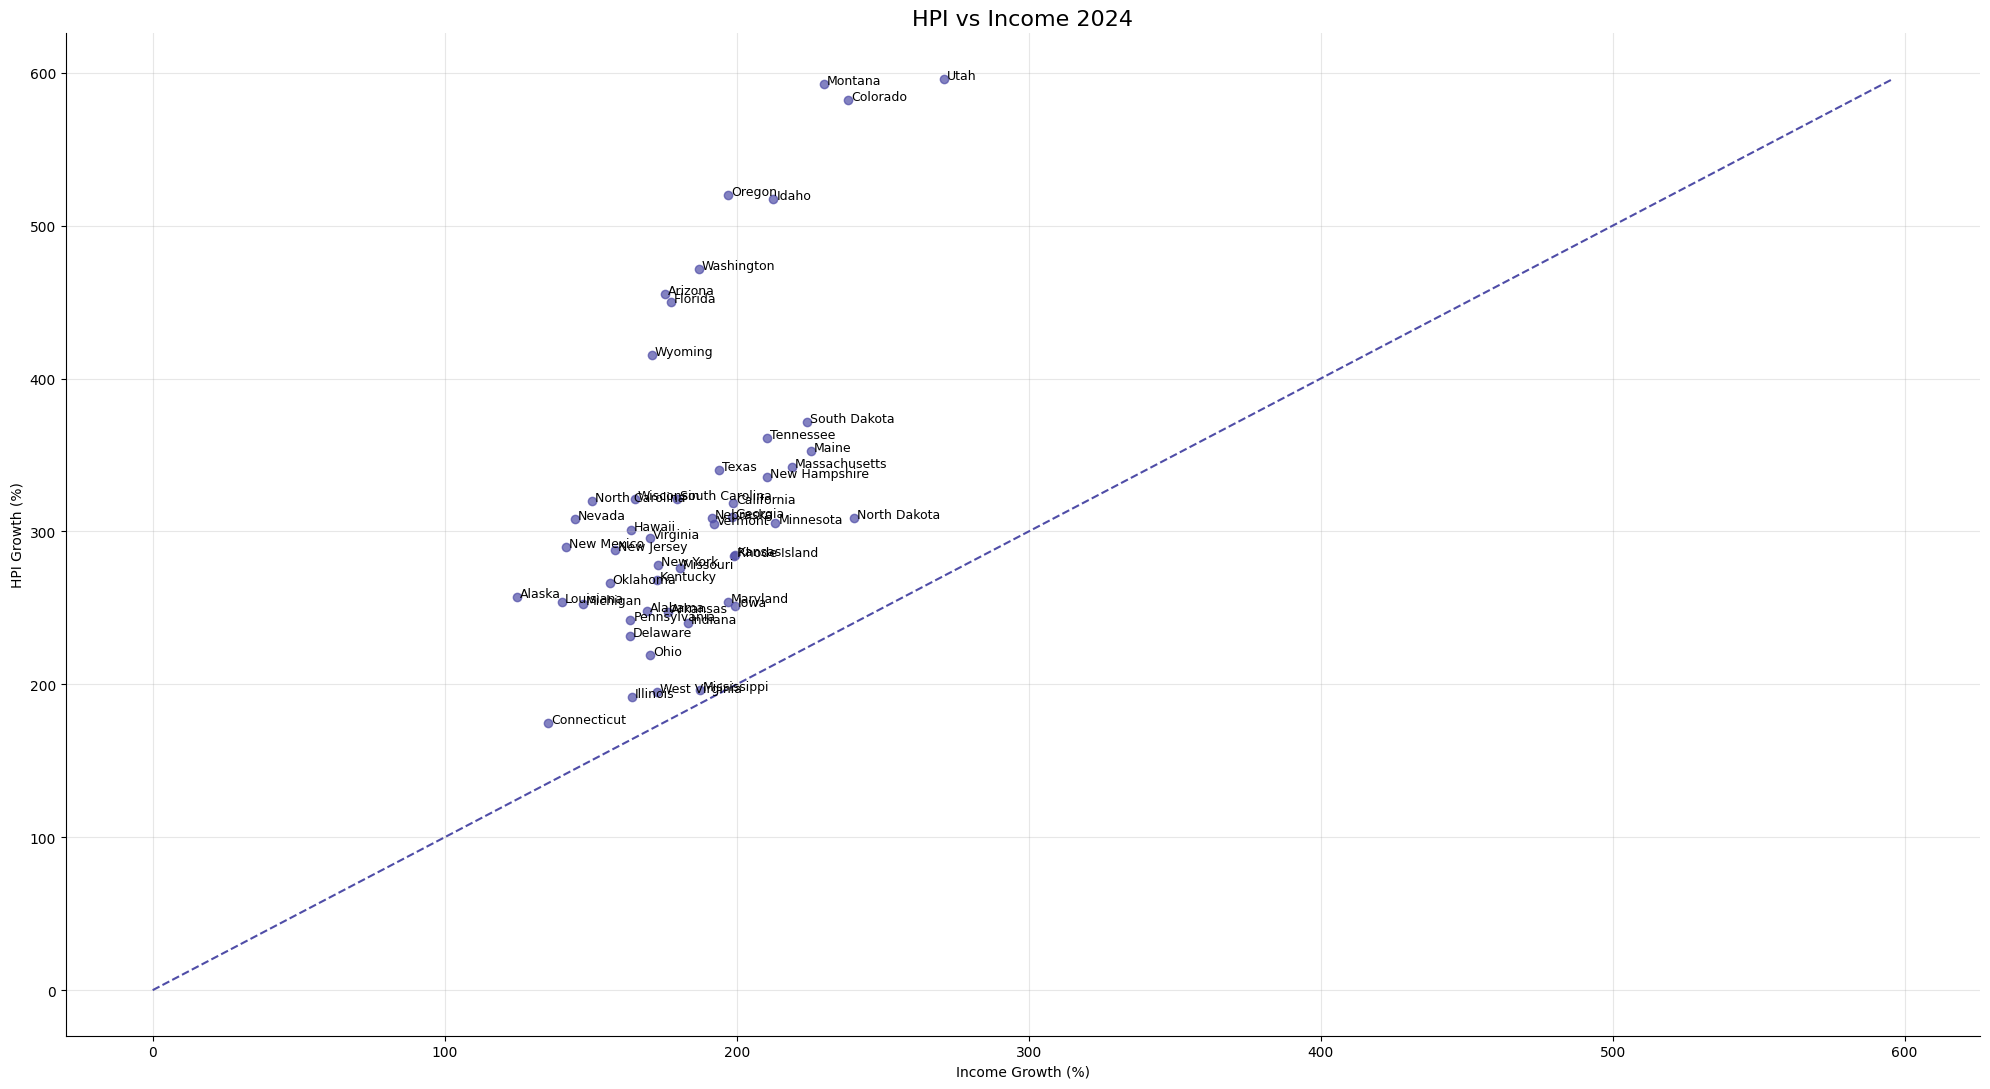

In [22]:
hpi_vs_income_scatter(2024)

Function which includes a query that returns HPI percent increase and Median Income percent increase for an given year between 1991 & 2024. The visual is a grouped bar chart

In [23]:
def hpi_vs_income_bar(year):

    df = query(f"""
    SELECT
        h.place_name,
        h.index_nsa AS hpi,
        m.change AS income_index
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.yr = {year}
    """)

    df = df.sort_values('hpi', ascending=False)

    x = np.arange(len(df))
    width = 0.35

    plt.figure(figsize=(15, 7))

    plt.bar(x - width/2, df['hpi'], width, label='HPI', color="#4f4da7")
    plt.bar(x + width/2, df['income_index'], width, label='Income', color="#A5A74D")

    plt.xticks(x, df['place_name'], rotation=45, ha='right')
    plt.title(f'HPI vs Income by State ({year})', fontsize=16,)
    plt.ylabel('HPI % Change')
    plt.xlabel('State')

    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

Call the function by choosing a year between 1991 and 2024

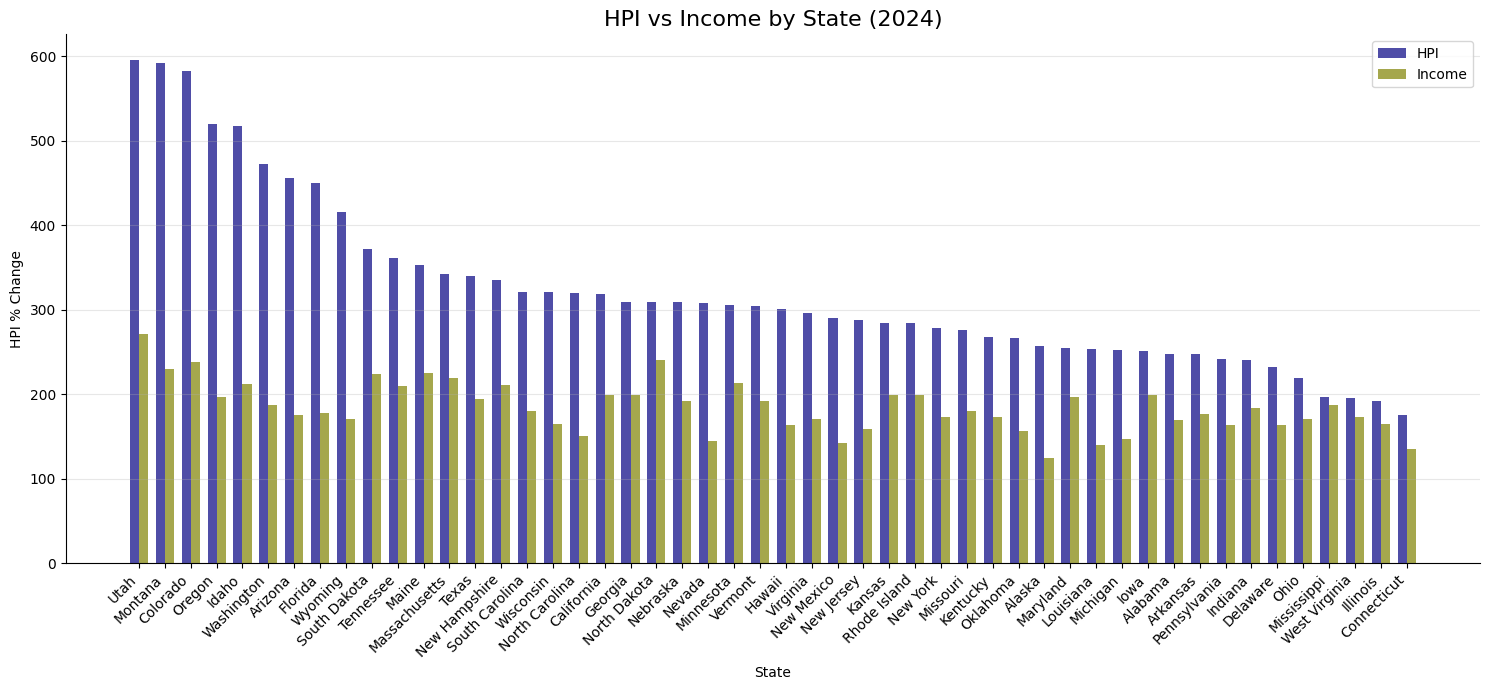

In [24]:
hpi_vs_income_bar(2024)

### I noticed a couple trends while looking at various states and years in the above visualizations. The years for those trends are 2007-2010 and 2019-2023. For both of these time periods significant factors influences the housing market. For the time period of 2007-2010 there was the US housing crisis. Then in 2020 the COVID-19 pandemic affected housing prices in the US in several ways. The peak for COVID-19 in the United States was 2022 which correlates directly with the peak of HPI in the United States

The following function queries for the gap between HSI and Median Income for all states and all years between 1991 and 2024. Loop: get all unique states, loop through each state, make df for each state, then code for line of data for each state where x-axis will be the year and y-axis will be the gap. The line graph also includes vertical reference lines denoting the Housing Crisis, COVID-19, and COVID-19 Peak

In [25]:
def affordability_over_time_all():

    df = query("""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    ORDER BY h.place_name, h.yr
    """)

    plt.figure(figsize=(14, 8))
    
    for state in df['place_name'].unique():
        subset = df[df['place_name'] == state]

        plt.plot(subset['yr'], subset['gap'], linewidth=1, alpha=0.5)        
        

    plt.axhline(0, linestyle='--', linewidth=1)

    plt.title('Housing Affordability Over Time (All States)', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('Gap (HPI - Income Index)')

    plt.grid(alpha=0.3)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.axvline(2008, color="#4f4da7", linewidth=1, alpha=0.5)
    plt.text(2008+0.2, 207, "Housing Crisis", color="#4f4da7", fontsize=12)
    plt.axvline(2020, color="#4f4da7", linewidth=1, alpha=0.5)
    plt.text(2017.6, 250, "COVID-19", color="#4f4da7", fontsize=12)
    plt.axvline(2022, color="#4f4da7", linewidth=1, alpha=0.5)
    plt.text(2022+0.2, 390, "COVID-19 Peak", color="#4f4da7", fontsize=12)

    plt.tight_layout()
    plt.show()

Call the function without any arguments

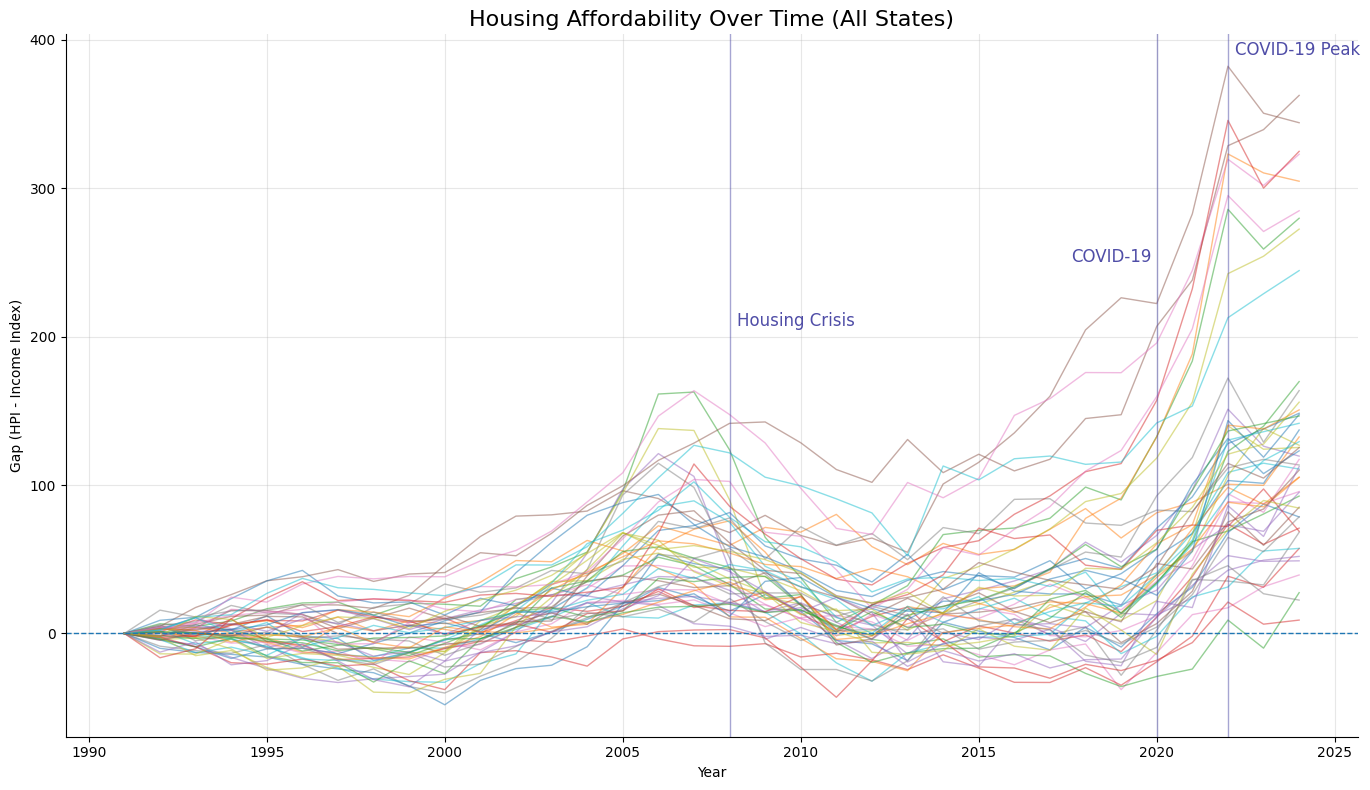

In [26]:
affordability_over_time_all()